In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit

In [81]:
TEMPS = np.array([130, 145, 180]) + 273
df = pd.DataFrame({"alcohol - 130": [20.92, 208.84, 285.76, 625.08],
                  "alcohol - 145": [20.4, 145.44, 191.4, 370.84],
                  "alcohol - 180": [19.64, 78, 91.44, 146.08]})

In [181]:
def count_gc_curve(T, t1, t0):
    return np.log((t1 - t0) / (np.sqrt(T) * t0))


def draw_gc_curve(T, values, name):
    
    plt.scatter(1/T, values, c='b', label=' Observed data')
    
    p = np.polyfit(1/T, values, 1)
    f = np.poly1d(p)
    slope, intercept, r_value, p_value, std_err = stats.linregress(1/T, values)
    
    plt.plot(1/T, f(1/T), c='r', label=f" Slope = {slope:.3f}\n Intercept = {intercept:.3f}\n Slope STD = {std_err:.3f}\n $R^2$ = {pow(r_value, 2):.5f}")
    
    plt.xlabel('$1/T, [K^{-1}]$')
    plt.ylabel('$f(T, t_1, t_0)$')
    
    plt.title(name)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return slope, std_err


def heat_adsorbtion(slope, error):
    return pd.DataFrame({"Heat of adsortion, kJ": [slope * 8.314 / 1000],
                         "Error, kJ": [error * 8.314 / 1000]}).T

In [82]:
water_values = count_gc_curve(TEMPS, df.T[1], df.T[0])
methanol_values = count_gc_curve(TEMPS, df.T[2], df.T[0])
ethanol_values = count_gc_curve(TEMPS, df.T[3], df.T[0])

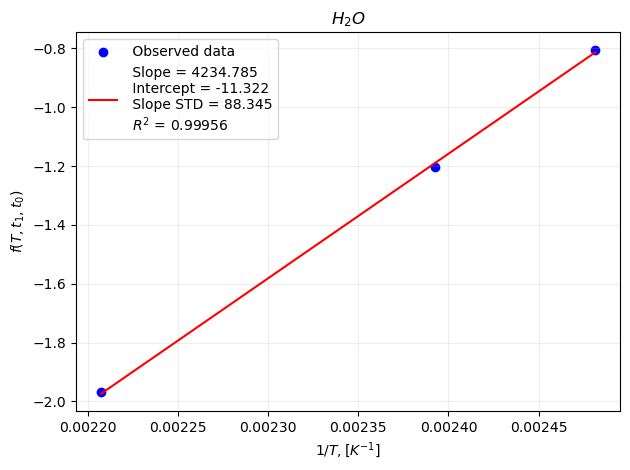

,0
"Heat of adsortion, kJ",35.207999
"Error, kJ",0.734500


In [182]:
s, e = draw_gc_curve(TEMPS, water_values, "$H_2O$")
heat_adsorbtion(s, e)

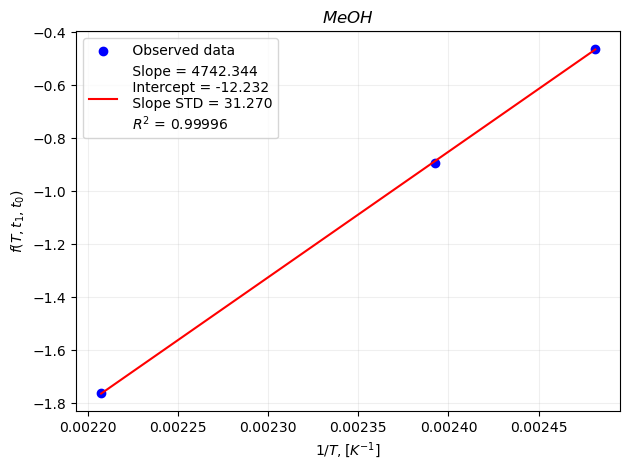

,0
"Heat of adsortion, kJ",39.427848
"Error, kJ",0.259977


In [183]:
s, e = draw_gc_curve(TEMPS, methanol_values, "$MeOH$")
heat_adsorbtion(s, e)

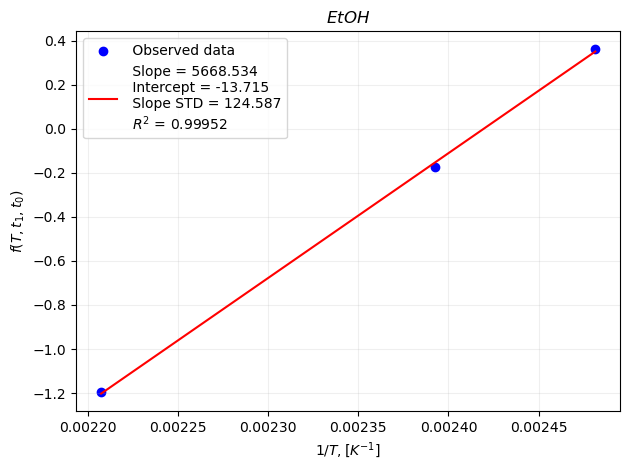

,0
"Heat of adsortion, kJ",47.128192
"Error, kJ",1.035819


In [184]:
s, e = draw_gc_curve(TEMPS, ethanol_values, "$EtOH$")
heat_adsorbtion(s, e)

In [7]:
velocity = [7, 10, 14, 20, 30, 45, 60]
data_7 = pd.DataFrame({"sigma": [3.375796178, 13.82165605, 6.900212314, 19.73248408],
                      "t": [53.04, 219.76, 268.96, 424.24]})
data_10 = pd.DataFrame({"sigma": [2.547770701, 9.762208068, 2.649681529, 21.37154989],
                       "t": [45.4, 173.96, 211.84, 320.84]})
data_14 = pd.DataFrame({"sigma": [1.83014862, 6.225053079, 2.67940552, 20.6836518],
                       "t": [34.32, 134.64, 160.24, 261.24]})
data_20 = pd.DataFrame({"sigma": [1.278131635, 3.732484076, 4.233545648, 6.81104034],
                       "t": [26.16, 103.72, 121.32, 195.12]})
data_30 = pd.DataFrame({"sigma": [0.866242038, 2.836518047, 4.050955414, 5.01910828],
                       "t": [19.64, 78, 91.44, 146.08]})
data_45 = pd.DataFrame({"sigma": [0.598726115, 2.55626327, 1.11252653, 4.751592357],
                       "t": [14.36, 58.28, 68.76, 111.96]})
data_60 = pd.DataFrame({"sigma": [0.47133758, 2.199575372, 0.535031847, 3.592356688],
                       "t": [11.32, 47.92, 56.4, 90.36]})
sequence = [data_7, data_10, data_14, data_20, data_30, data_45, data_60]
df_name = ['data_7', 'data_10', 'data_14', 'data_20', 'data_30', 'data_45', 'data_60']
for i in range(len(df_name)):
    print(df_name[i])
    print(sequence[i])

data_7
       sigma       t
0   3.375796   53.04
1  13.821656  219.76
2   6.900212  268.96
3  19.732484  424.24
data_10
       sigma       t
0   2.547771   45.40
1   9.762208  173.96
2   2.649682  211.84
3  21.371550  320.84
data_14
       sigma       t
0   1.830149   34.32
1   6.225053  134.64
2   2.679406  160.24
3  20.683652  261.24
data_20
      sigma       t
0  1.278132   26.16
1  3.732484  103.72
2  4.233546  121.32
3  6.811040  195.12
data_30
      sigma       t
0  0.866242   19.64
1  2.836518   78.00
2  4.050955   91.44
3  5.019108  146.08
data_45
      sigma       t
0  0.598726   14.36
1  2.556263   58.28
2  1.112527   68.76
3  4.751592  111.96
data_60
      sigma      t
0  0.471338  11.32
1  2.199575  47.92
2  0.535032  56.40
3  3.592357  90.36


In [127]:
water_table = pd.DataFrame({"R": [i["t"][1]/i["sigma"][1] for i in sequence],
                     "HETP": [(i["sigma"][1]/i["t"][1])**2 for i in sequence],
                     "r": [(2 *(i["t"][1]/i["sigma"][1]))**2 for i in sequence]})
water_table.index = velocity
water_table

,R,HETP,r
7,15.899687,0.003956,1011.200141
10,17.819739,0.003149,1270.172395
14,21.628731,0.002138,1871.208060
20,27.788464,0.001295,3088.794963
30,27.498503,0.001322,3024.670667
45,22.798904,0.001924,2079.160031
60,21.786023,0.002107,1898.523221


In [126]:
methanol_table = pd.DataFrame({"R": [i["t"][2]/i["sigma"][2] for i in sequence],
                     "HETP": [(i["sigma"][2]/i["t"][2])**2 for i in sequence],
                     "r": [(2 *(i["t"][2]/i["sigma"][2]))**2 for i in sequence]})
methanol_table.index = velocity
methanol_table

,R,HETP,r
7,38.978511,0.000658,6077.297208
10,79.949231,0.000156,25567.517996
14,59.804311,0.000280,14306.222276
20,28.656830,0.001218,3284.855735
30,22.572453,0.001963,2038.062507
45,61.805268,0.000262,15279.564457
60,105.414286,0.000090,44448.686553


In [168]:
ethanol_table = pd.DataFrame({"R": [i["t"][3]/i["sigma"][3] for i in sequence],
                     "HETP": [(i["sigma"][3]/i["t"][3])**2 for i in sequence],
                     "r": [(2 *(i["t"][3]/i["sigma"][3]))**2 for i in sequence]})
ethanol_table.index = velocity
ethanol_table

,R,HETP,r
7,21.499574,0.002163,1848.926714
10,15.012482,0.004437,901.498418
14,12.630265,0.006269,638.094359
20,28.647606,0.001218,3282.741314
30,29.104772,0.001181,3388.350914
45,23.562627,0.001801,2220.789629
60,25.153404,0.001581,2530.774982


In [131]:
def van_deemter(V0, A, B, C):
    return A * V0 + B / V0 + C

initial_guess = [0.5, 2.0, 3.0]

V_opt_water = 27.966204398303145, error = 7.759602339741839


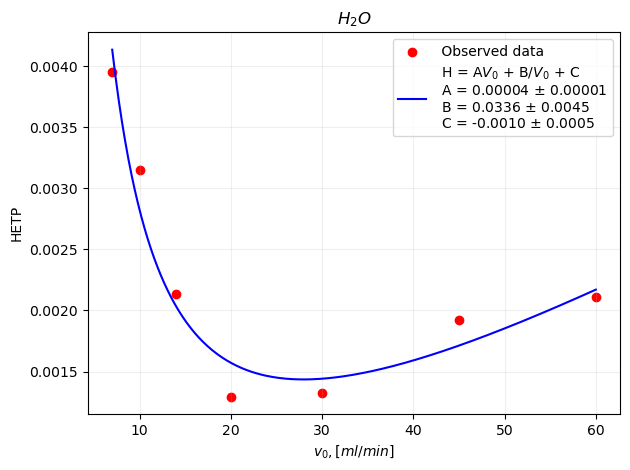

In [180]:
plt.scatter(velocity, water_table["HETP"], c='r', label=' Observed data')

params, covariance = curve_fit(van_deemter, velocity, water_table["HETP"], p0=initial_guess)
A_fit, B_fit, C_fit = params
errors = np.sqrt(np.diag(covariance))
velocity_smooth = np.linspace(min(velocity), max(velocity), 300)
H_fit = van_deemter(velocity_smooth, A_fit, B_fit, C_fit)
plt.plot(velocity_smooth, H_fit, 'b', label=f" H = A$V_0$ + B/$V_0$ + C\n A = {A_fit:.5f} $\pm$ {errors[0]:.5f}\n B = {B_fit:.4f} $\pm$ {errors[1]:.4f}\n C = {C_fit:.4f} $\pm$ {errors[2]:.4f}")

print(f"V_opt_water = {np.sqrt(B_fit / A_fit)}, error = {np.sqrt(B_fit / A_fit) * np.sqrt((errors[0]/A_fit)**2 + (errors[1]/B_fit)**2)}")

plt.title("$H_2O$")
plt.xlabel("$v_0, [ml/min]$")
plt.ylabel("HETP")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

а дальше пошли костыли

In [162]:
print(methanol_table["HETP"][:3])
print(methanol_table["HETP"][-2:])

7     0.000658
10    0.000156
14    0.000280
Name: HETP, dtype: float64
45    0.000262
60    0.000090
Name: HETP, dtype: float64


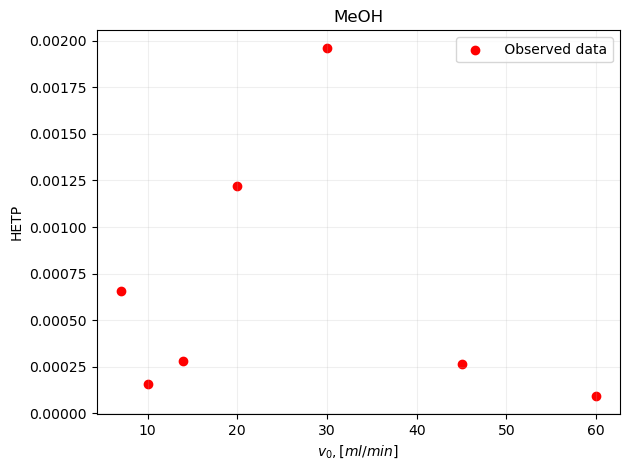

In [177]:
plt.scatter(velocity, methanol_table["HETP"], c='r', label=' Observed data')

plt.title("MeOH")
plt.xlabel("$v_0, [ml/min]$")
plt.ylabel("HETP")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

V_opt_meth = 26.75832040489247, error = 59.65141678785421


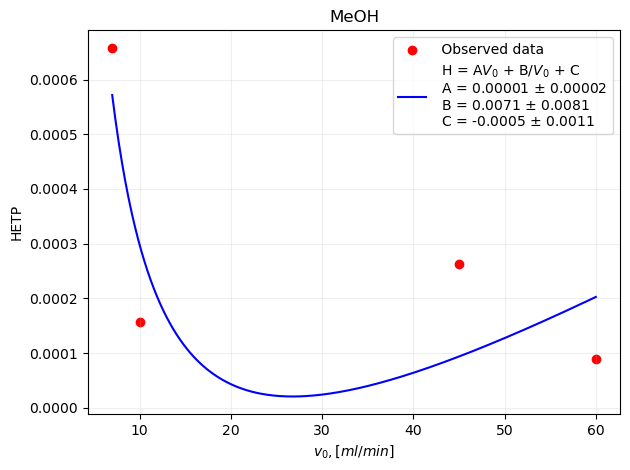

In [176]:
v_kost_meth = velocity[:2] + velocity[-2:]
h_kost_meth = np.array([0.000658, 0.000156, 0.000262, 0.000090])
plt.scatter(v_kost_meth, h_kost_meth, c='r', label=' Observed data')

params, covariance = curve_fit(van_deemter, v_kost_meth, h_kost_meth, p0=initial_guess)
A_fit, B_fit, C_fit = params
errors = np.sqrt(np.diag(covariance))
velocity_smooth = np.linspace(min(velocity), max(velocity), 300)
H_fit = van_deemter(velocity_smooth, A_fit, B_fit, C_fit)
plt.plot(velocity_smooth, H_fit, 'b', label=f" H = A$V_0$ + B/$V_0$ + C\n A = {A_fit:.5f} $\pm$ {errors[0]:.5f}\n B = {B_fit:.4f} $\pm$ {errors[1]:.4f}\n C = {C_fit:.4f} $\pm$ {errors[2]:.4f}")

print(f"V_opt_meth = {np.sqrt(B_fit / A_fit)}, error = {np.sqrt(B_fit / A_fit) * np.sqrt((errors[0]/A_fit)**2 + (errors[1]/B_fit)**2)}")

plt.title("MeOH")
plt.xlabel("$v_0, [ml/min]$")
plt.ylabel("HETP")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [188]:
print(ethanol_table["HETP"][:1])
print(ethanol_table["HETP"][-4:])

7    0.002163
Name: HETP, dtype: float64
20    0.001218
30    0.001181
45    0.001801
60    0.001581
Name: HETP, dtype: float64


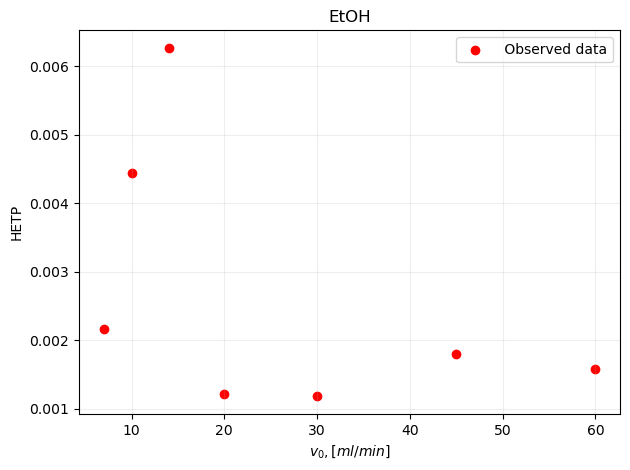

In [174]:
plt.scatter(velocity, ethanol_table["HETP"], c='r', label=' Observed data')

plt.title("EtOH")
plt.xlabel("$v_0, [ml/min]$")
plt.ylabel("HETP")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

V_opt_eth = 23.729140405780633, error = 15.356723905775345


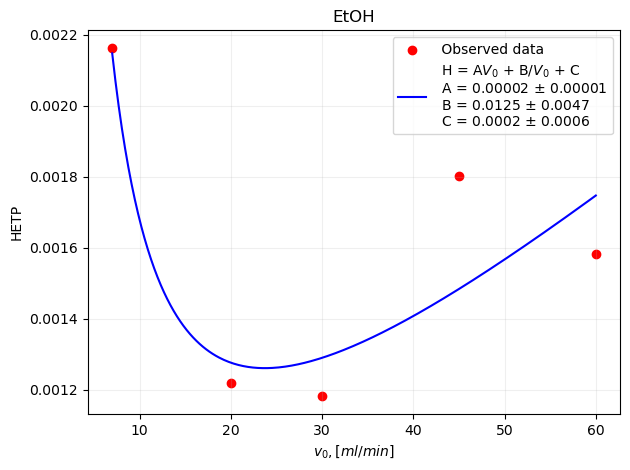

In [187]:
v_kost_eth = velocity[:1] + velocity[-4:]
h_kost_eth = np.array([0.002163, 0.001218, 0.001181, 0.001801, 0.001581])
plt.scatter(v_kost_eth, h_kost_eth, c='r', label=' Observed data')

params, covariance = curve_fit(van_deemter, v_kost_eth, h_kost_eth, p0=initial_guess)
A_fit, B_fit, C_fit = params
errors = np.sqrt(np.diag(covariance))
velocity_smooth = np.linspace(min(velocity), max(velocity), 300)
H_fit = van_deemter(velocity_smooth, A_fit, B_fit, C_fit)
plt.plot(velocity_smooth, H_fit, 'b', label=f" H = A$V_0$ + B/$V_0$ + C\n A = {A_fit:.5f} $\pm$ {errors[0]:.5f}\n B = {B_fit:.4f} $\pm$ {errors[1]:.4f}\n C = {C_fit:.4f} $\pm$ {errors[2]:.4f}")

print(f"V_opt_eth = {np.sqrt(B_fit / A_fit)}, error = {np.sqrt(B_fit / A_fit) * np.sqrt((errors[0]/A_fit)**2 + (errors[1]/B_fit)**2)}")

plt.title("EtOH")
plt.xlabel("$v_0, [ml/min]$")
plt.ylabel("HETP")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()